In [14]:
# Imports
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import os


def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "README.md").exists() and (candidate / "data").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)

In [15]:
# PISC Semianalytical Fits (Schmitz 2021)
def calc_pisc_lisa(f, channel="s", f_t_h_star=100):
    """
    Calculate the PISC sensitivity curve values (h²Ω_PIS) for LISA.

    Args:
    - f (np.array): Frequency array (Hz).
    - channel (str): "b", "s", or "t" for bubble, sound wave, or turbulence channels.
    - f_t_h_star (float): Ratio of turbulence peak frequency to Hubble rate at transition.

    Return:
    - h2omega (np.array): PISC sensitivity curve values (h²Ω_PIS) corresponding to input frequencies.
    """

    x = np.asarray(f) / 1e-3 # Convert frequency to mHz

    # Calculate h²Ω_PIS based on the specified channel
    if channel == "b":
        h2omega = 1e-14 * (2.63 * x**-1 + 3.26e-1 * x**1 + 3.29e-3 * x**2 + 4.67e-3 * x**2.8)
    elif channel == "s":
        h2omega = 1e-14 * (3.58e-3 * x**-4 + 3.26e-1 * x**-3 + 1.20 * x**-2 + 2.48 * x**-1 
                           + 2.85e-1 * x**1 + 1.81e-2 * x**2 + 1.50e-3 * x**3)
    elif channel == "t":
        x_th = f_t_h_star
        h2omega = 1e-12 * (1.07 * x_th**0.98 * x**-(5/3) + 1.96 * x_th**1.04 * x**-1 + 3.50 * x_th**0.96 * x**0 
                           + 4.77e-1 * x_th**1.03 * x**1 + 3.32e-2 * x_th**0.96 * x**2 + 1.05e-4 * x_th**0.05 * x**3)
    return h2omega

def calc_pisc_bbo(f, channel="s", f_t_h_star=100):
    """
    Calculate the PISC sensitivity curve values (h²Ω_PIS) for BBO.

    Args:
    - f (np.array): Frequency array (Hz).
    - channel (str): "b", "s", or "t" for bubble, sound wave, or turbulence channels.
    - f_t_h_star (float): Ratio of turbulence peak frequency to Hubble rate at transition.

    Return:
    - h2omega (np.array): PISC sensitivity curve values (h²Ω_PIS) corresponding to input frequencies.
    """

    x = np.asarray(f) / 1e-3 # Convert frequency to mHz

    # Calculate h²Ω_PIS based on the specified channel
    if channel == "b":
        h2omega = 1e-16 * (8.24 * x**-1 + 1.61e-2 * x**0 + 1.98e-4 * x**1 + 4.24e-9 * x**2 
                           + 2.06e-9 * x**2.8)
    elif channel == "s":
        h2omega = 1e-14 * (1.77e-1 * x**-4 + 1.06 * x**-1.5 + 1.35e-4 * x**0 + 2.23e-6 * x**1 
                           + 1.29e-9 * x**2 + 2.99e-12 * x**3)
    elif channel == "t":
        x_th = f_t_h_star
        h2omega = 1e-13 * (2.44 * x_th**1.00 * x**-(5/3) + 1.41 * x_th**1.00 * x**-1 + 1.00e-2 * x_th**1.00 * x**0 
                           + 5.06e-5 * x_th**1.00 * x**1 + 3.19e-8 * x_th**0.98 * x**2 + 1.37e-12 * x_th**0.31 * x**3)
    return h2omega
    
def calc_pisc_decigo(f, channel="s", f_t_h_star=100):
    """
    Calculate the PISC sensitivity curve values (h²Ω_PIS) for DECIGO.

    Args:
    - f (np.array): Frequency array (Hz).
    - channel (str): "b", "s", or "t" for bubble, sound wave, or turbulence channels.
    - f_t_h_star (float): Ratio of turbulence peak frequency to Hubble rate at transition.

    Return:
    - h2omega (np.array): PISC sensitivity curve values (h²Ω_PIS) corresponding to input frequencies.
    """

    x = np.asarray(f) / 1e-3 # Convert frequency to mHz

    # Calculate h²Ω_PIS based on the specified channel
    if channel == "b":
        h2omega = 1e-15 * (2.06 * x**-1 + 7.61e-3 * x**0 + 4.58e-5 * x**1 + 2.19e-7 * x**2 
                           + 6.35e-10 * x**2.8)
    elif channel == "s":
        h2omega = 1e-14 * (3.82e-1 * x**-4 + 2.26 * x**-1.5 + 1.10e-3 * x**0 + 2.56e-6 * x**1 
                           + 2.91e-8 * x**2 + 7.54e-12 * x**3)
    elif channel == "t":
        x_th = f_t_h_star
        h2omega = 1e-13 * (5.31 * x_th**1.00 * x**-(5/3) + 3.34 * x_th**1.00 * x**-1 + 3.75e-2 * x_th**0.99 * x**0 
                           + 2.16e-4 * x_th**1.01 * x**1 + 1.92e-7 * x_th**0.96 * x**2 + 9.33e-12 * x_th**0.07 * x**3)
    return h2omega

In [16]:
# FOPT Frequency Peak, Amplitude, and Spectral Shape Formulas (Caprini 2016)
def calc_f_peak(beta_H_star, v_w, T_star=100.0, g_star=106.75, channel="s"):
    """
    Calculate the peak frequency of the GW signal based on FOPT parameters.
    
    Args:
    - beta_H_star (float): Inverse duration of the phase transition in units of the Hubble rate at transition.
    - v_w (float): Velocity of the bubble wall.
    - T_star (float): Temperature at transition. Default is 100 GeV.
    - g_star (float): Number of relativistic degrees of freedom at transition. Default is 106.75.
    - channel (str): "b", "s", or "t" for bubble, sound wave, or turbulence channels. Default is "s".

    Returns:
    - float: Peak frequency of the GW signal from turbulence (Hz).
    """
    
    # Calculate f_peak based on the specified channel
    if channel == "b":
        f_peak = 1.6e-5 * (g_star / 100.0)**(1/6) * (T_star / 100.0) * (beta_H_star / v_w) * (0.62 * v_w / (1.8 - 0.1 * v_w + v_w**2))
    elif channel == "s":
        f_peak = 1.9e-5 * (g_star / 100.0)**(1/6) * (T_star / 100.0) * (beta_H_star / v_w)
    elif channel == "t":
        f_peak = 2.7e-5 * (g_star / 100.0)**(1/6) * (T_star / 100.0) * (beta_H_star / v_w)

    return f_peak

def calc_kappa_s(alpha, v_w):
    """
    Piecewise kappa_s calculation for both fast and slow walls (Schmitz 2020).
    
    Args:
    - alpha (float): Strength of the phase transition.
    - v_w (float): Velocity of the bubble wall.

    Returns:
    - kappa_s (float): Efficiency factor for sound wave contribution to GW production.
    """

    # Calculate the critical velocity v_w_alpha that separates the fast and slow wall regimes
    num = 1.36 - 0.037 * np.sqrt(alpha) + alpha
    den = 6.9 * (0.73 + 0.083 * np.sqrt(alpha) + alpha)
    v_w_alpha = (num / den)**(5/6)
    
    if v_w >= v_w_alpha:
        kappa_s = alpha / (0.73 + 0.083 * np.sqrt(alpha) + alpha)
    else:
        kappa_s = (6.9 * alpha * v_w**(6/5)) / (1.36 - 0.037 * np.sqrt(alpha) + alpha)

    return kappa_s

def calc_h2omega_peak(alpha, beta_H_star, v_w, g_star=106.75, channel="s", eps_turb=0.1):
    """
    Calculate the peak amplitude of the GW signal based on FOPT parameters.

    Args:
    - alpha (float): Strength of the phase transition.
    - beta_H_star (float): Inverse duration of the phase transition in units of the Hubble rate at transition.
    - v_w (float): Velocity of the bubble wall.
    - T_star (float): Temperature at transition. Default is 100 GeV.
    - g_star (float): Number of relativistic degrees of freedom at transition. Default is 106.75.
    - channel (str): "s" or "t" for sound wave or turbulence channels. Default is "s".
    - eps_turb (float): Efficiency factor for turbulence contribution. Default is 0.1.

    Returns:
    - h2omega_peak (float): Peak amplitude of the GW signal (h²Ω_peak).
    """
    
    # Calculate h²Ω_peak based on the specified channel
    kappa_s = calc_kappa_s(alpha, v_w)

    if channel == "s":
        h2omega_peak = 2.65e-6 * (v_w / beta_H_star) * (100 / g_star)**(1/3) * (kappa_s * alpha / (1 + alpha))**2 
    elif channel == "t":
        kappa_t = eps_turb * kappa_s
        h2omega_peak = 3.35e-4 * (v_w / beta_H_star) * (100 / g_star)**(1/3) * (kappa_t * alpha / (1 + alpha))**(3/2)

    return h2omega_peak

def calc_h_star(T_star=100.0, g_star=106.75):
    """
    Calculate the Hubble frequency.

    Args:
    - T_star (float): Temperature at transition. Default is 100 GeV.
    - g_star (float): Number of relativistic degrees of freedom at transition. Default is 106.75.

    Returns:
    - h_star (float): Hubble frequency corresponding to the transition temperature (Hz).
    """
    
    # Calculate the Hubble frequency
    h_star = 1.65e-5 * (g_star / 100.0)**(1/6) * (T_star / 100.0)
    
    return h_star

def calc_spectral_shape(f, f_peak, channel="s", h_star=None):
    """
    Calculate the spectral shape function S(f).

    Args:
    - f (np.array): Frequency array (Hz).
    - f_peak (float): Peak frequency of the GW signal (Hz).
    - channel (str): "b", "s", or "t" for bubble, sound wave, or turbulence channels.
    - h_star (float): Hubble frequency at transition (Hz).

    Returns:
    - np.array: Spectral shape function values corresponding to input frequencies.
    """
    
    f_ratio = f / f_peak # Calculate the frequency ratio
    
    # Calculate the spectral shape based on the specified channel
    if channel == "b":
        shape = (f_ratio)**2.8 * (3.8 / (1.0 + 2.8 * f_ratio**3.8))
    elif channel == "s":
        shape = (f_ratio)**3 * (7.0 / (4.0 + 3.0 * f_ratio**2))**(7/2)
    elif channel == "t":
        if h_star is None:
            raise ValueError("h_star must be provided for the turbulence channel shape function.")
        shape = (f_ratio)**3 * (1 / (1 + f_ratio))**(11/3) * (1 / (1 + 8 * np.pi * f / h_star))

    return shape

In [17]:
def calc_h2omega_t_RP2023(f, alpha, beta_H_star, v_w, kappa_v, T_star=100.0, g_star=106.75, eps_turb=0.10):
    """
    Calculate the full GW spectrum from MHD turbulence using the Roper Pol 2023 model. (arXiv: 2307.10744)
    
    Args:
    - f (np.array): Frequency array (Hz).
    - alpha (float): Strength of the phase transition.
    - beta_H_star (float): Inverse duration of the phase transition (beta / H_*).
    - v_w (float): Velocity of the bubble wall.
    - kappa_v (float): Fraction of vacuum energy converted to kinetic energy.
    - T_star (float): Temperature at transition in GeV. Default is 100.
    - g_star (float): Relativistic degrees of freedom. Default is 106.75.
    - eps_turb (float): Fraction of kinetic energy converted to turbulence. Default is 0.1.
    
    Returns:
    - h2omega_t_rp (np.array): h^2 Omega_t(f) spectrum for turbulence based on the Roper Pol 2023 model.
    """
    
    # Cosmological Prefactors & Hubble Frequency
    # Hubble frequency today mapped from transition
    f_H = 1.65e-5 * (T_star / 100.0) * (g_star / 100.0)**(1/6) # Hz
    
    # GW transfer function prefactor (Eq 8)
    F0_GW = 1.64e-5 * (100.0 / g_star)**(1/3)
    
    # Turbulence Energetics (Eq 5, 10, 13)
    K = kappa_v * alpha / (1.0 + alpha)
    Omega_star = eps_turb * K
    u_star = np.sqrt(0.75 * Omega_star) 
    
    # Characteristic Scales
    c_s = 1.0 / np.sqrt(3.0)
    # Comoving bubble size at percolation (Eq 1)
    lambda_H_star = (8.0 * np.pi)**(1/3) * max(v_w, c_s) / beta_H_star
    
    # Effective turbulence duration (Eq 13 below, N_eddy ~ 2)
    N_eddy = 2.0
    H_dt_fin = N_eddy * lambda_H_star / u_star
    
    # Dimensionless Frequencies (s1 and s3)
    s1 = (f / f_H) * lambda_H_star
    s3 = (f / f_H) * H_dt_fin
    
    # Anisotropic Stress Power Spectrum (Eq 17)
    alpha_Pi = 2.15
    s_Pi = 2.2
    p_Pi = (1.0 + (s1 / s_Pi)**alpha_Pi)**(-11.0 / (3.0 * alpha_Pi))
    
    # Evaluate at the peak of the GW spectrum (Eq 19a, 19b)
    s_turb = 1.4
    p_Pi_peak = 0.6
    
    # Time Sourcing Function T_GW (Eq 15)
    T_GW = np.zeros_like(f)
    mask_low = s3 < 1.0
    mask_high = s3 >= 1.0
    
    T_GW[mask_low] = np.log(1.0 + H_dt_fin / (2 * np.pi))**2
    T_GW[mask_high] = np.log(1.0 + lambda_H_star / (2 * np.pi * s1[mask_high]))**2
    
    # S_turb Spectral Shape (Eq 14)
    S_turb = ((4.0 * np.pi**2 * s1**3 * T_GW) / (lambda_H_star**2)) * (p_Pi / (s_turb * p_Pi_peak))
    
    # Total GW Spectrum (Eq 9)
    A = 1.75e-3 # Normalization efficiency factor (Eq 20)
    h2omega_t_rp = 3.0 * A * (Omega_star**2) * (lambda_H_star**2) * F0_GW * S_turb
    
    return h2omega_t_rp

In [18]:
def calc_p_m(mu5_T_star, v_w):
    """Calculate the fractional magnetic helicity from chiral dynamo scaling law.
    
    Args:
    - mu5_T_star (float): Ratio of chiral chemical potential to temperature at transition.
    - v_w (float): Velocity of the bubble wall.
    
    Returns:
    - p_m (float): Fractional magnetic helicity that determines the chiral GW amplitude.
    """

    p_m = 6e-4 * mu5_T_star / v_w
    
    return p_m

In [19]:
def _load_plis_dat(filepath):
    """
    Load, clean, and convert PLIS data from a Roper Pol .dat file.
    Transforms log-scale inputs, drops non-finite rows, and ensures validity for plotting.

    Args:
    - filepath (str): Path to the .dat file.

    Returns:
    - f_clean (np.array): Cleaned frequency array (Hz).
    - omega_clean (np.array): Cleaned power-law integrated sensitivity (h²Ω_PLIS).
    """
    
    # Load raw data, skipping the 14-line metadata header
    data = np.loadtxt(filepath, skiprows=14)
    
    # Safety check for empty or completely corrupted files
    if data.size == 0 or data.ndim < 2:
        raise ValueError(f"No valid numerical data structure found in {filepath}.")
        
    # Extract columns and convert from Log10 representation back to linear scale
    f = 10**data[:, 0]
    omega_plis = 10**data[:, 1]
    
    # Combine all filtering logic into a single, clean mask
    # Ensures no NaNs or Infs made it through the transformation
    mask = np.isfinite(f) & np.isfinite(omega_plis)
    f_clean, omega_clean = f[mask], omega_plis[mask]
    
    # Raise an explicit error if everything was filtered out
    if len(f_clean) == 0:
        raise ValueError(f"No valid data rows left after processing and filtering {filepath}")

    return f_clean, omega_clean

def _load_xipls_csv(filepath):
    """
    Load, clean, and filter a two-column CSV (freq, value).
    Drops rows with empty columns, non-positive values (essential for log-scaling), and infinite/NaN values.

    Args:
    - filepath (str): Path to the CSV file.

    Returns:
    - f_clean (np.array): Cleaned frequency array (Hz).
    - xi_clean (np.array): Cleaned corresponding values ready for plotting.
    """
    
    # Parse columns 1 and 2, converting missing entries directly to NaN
    data = np.genfromtxt(
        filepath, 
        delimiter=",", 
        skip_header=1, 
        usecols=(1, 2), 
        missing_values="",
        filling_values=np.nan
    )
    
    # Safety check for empty or completely corrupted files
    if data.size == 0 or data.ndim < 2:
        raise ValueError(f"No valid numerical data structure found in {filepath}.")
    
    f, xi = data[:, 0], data[:, 1]
    
    # Combine all filtering logic into a single, clean mask
    # Handles empty rows (NaN), zeros/negatives (invalid for log-plots), and Infs
    mask = np.isfinite(f) & np.isfinite(xi) & (xi > 0)
    f_clean, xi_clean = f[mask], xi[mask]
    
    # Raise an explicit error if everything was filtered out
    if len(f_clean) == 0:
        raise ValueError(f"No valid positive data rows left after filtering {filepath}")
        
    return f_clean, xi_clean

In [20]:
def calc_scale(snr_new, T_new, snr_ref=10, T_ref=4):
    """
    Calculate the scaling factor for the polarization sensitivity curve based on new SNR and observation time.

    Args:
    - snr_new (float): New signal-to-noise ratio threshold.
    - T_new (float): New observation time in years.
    - snr_ref (float): Reference SNR threshold. Default is 10.
    - T_ref (float): Reference observation time in years. Default is 4.

    Returns:
    - scale (float): Scaling factor to apply to the polarization sensitivity curve.
    """
    
    # The SNR scales with the square root of the observation time and linearly with the amplitude
    scale = (snr_new / snr_ref) * np.sqrt(T_ref / T_new)
    
    return scale

In [21]:
# FOPT Benchmarks (α, β/H*, v_w) for plotting GW spectra and chirality predictions
bps_fopt = [
    # BM1: Extreme supercooling & long duration. 
    # Varies ONLY in alpha from BM2 to isolate the impact of ultra-strong vacuum energy (optimistic thesis point).
    {"label": "Ultra-strong", "alpha": 2.0, "beta_H_star": 5, "v_w": 0.7, "color": "darkred"}, 

    # BM2: Strong detonation. 
    # High latent heat release with a supersonic wall; slightly stronger central reference point.
    {"label": "Strong, fast", "alpha": 0.6, "beta_H_star": 10, "v_w": 0.7, "color": "crimson"}, 

    # BM3: Strong deflagration. 
    # Varies ONLY in v_w from BM2 to isolate wall-speed suppression.
    {"label": "Strong, slow", "alpha": 0.6, "beta_H_star": 10, "v_w": 0.1, "color": "darkorange"}, 

    # BM4: Moderate transition. 
    # Standard reference point for typical BSM scenarios with intermediate strength and duration.
    {"label": "Moderate", "alpha": 0.1, "beta_H_star": 100, "v_w": 0.5, "color": "forestgreen"},

    # BM5: Weak, highly localized transition. 
    # Short duration and minimal vacuum energy; serves as the "null-signal" baseline.
    {"label": "Weak", "alpha": 0.05, "beta_H_star": 500, "v_w": 0.3, "color": "cadetblue"}
]

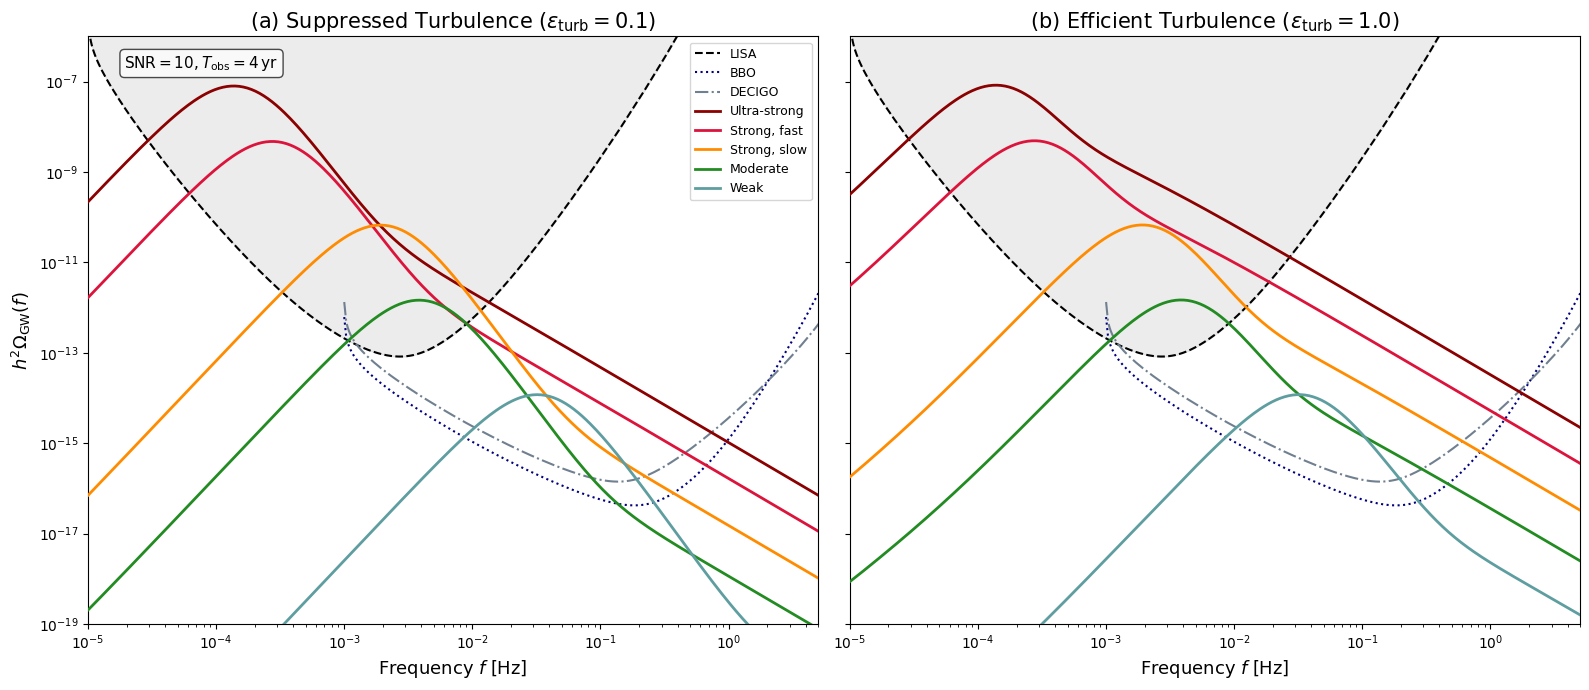

In [22]:
# Figure 7.1: Total-Intensity GW Detectability (1x2 Panel Layout)

# Load PLIS data from DAT files for LISA, BBO, and DECIGO
plis_folder = PROJECT_ROOT / "data" / "sensitivity" / "power-law-integrated_sensitivities"
f_lisa, o_lisa = _load_plis_dat(os.path.join(plis_folder, "plis_LISA.dat"))
f_bbo, o_bbo = _load_plis_dat(os.path.join(plis_folder, "plis_BBO.dat"))
f_decigo, o_decigo = _load_plis_dat(os.path.join(plis_folder, "plis_DECIGO.dat"))

# Create a 1x2 panel figure for GW detectability
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Common frequency axis
f_axis = np.logspace(-6, 2, 500)

# Scaling factor for PLIS curves
snr_new = 10 # New SNR threshold
period_new = 4 # New observation period in years
scale_plis = calc_scale(snr_new=snr_new, T_new=period_new, snr_ref=1, T_ref=1)

# Rescale the PLIS data
o_lisa_scaled = o_lisa * scale_plis
o_bbo_scaled = o_bbo * scale_plis
o_decigo_scaled = o_decigo * scale_plis

# Setup the two cases for the loop
eps_turb_values = [0.1, 1.0]
panel_titles = [r"(a) Suppressed Turbulence ($\epsilon_{\rm turb} = 0.1$)", 
                r"(b) Efficient Turbulence ($\epsilon_{\rm turb} = 1.0$)"]

for ax, eps_turb, title in zip(axes, eps_turb_values, panel_titles):

    # PLIS Curves (channel-agnostic, correct for s+t total spectrum)
    ax.loglog(f_lisa, o_lisa_scaled, label="LISA", color="black", linestyle="--", lw=1.5, zorder=2)
    ax.loglog(f_bbo, o_bbo_scaled, label="BBO", color="navy", linestyle=":", lw=1.5, zorder=2)
    ax.loglog(f_decigo, o_decigo_scaled, label="DECIGO", color="slategray", linestyle="-.", lw=1.5, zorder=2)

    # Add faint shading for LISA's detectable region
    ax.fill_between(f_lisa, o_lisa_scaled, 1e-5, color="gray", alpha=0.15, zorder=1)

    # Total GW Spectra from FOPT Benchmarks
    for bp in bps_fopt:
        
        # Calculate peak frequency and amplitude for the sound wave channel
        f_peak_s = calc_f_peak(bp["beta_H_star"], bp["v_w"], channel="s")
        h2omega_peak_s = calc_h2omega_peak(bp["alpha"], bp["beta_H_star"], bp["v_w"], channel="s")
        
        # Generate the sound wave spectrum
        h2omega_s = h2omega_peak_s * calc_spectral_shape(f_axis, f_peak_s, channel="s")
        
        # Calculate peak frequency and amplitude for the turbulence channel (Dependent on eps_turb)
        f_peak_t = calc_f_peak(bp["beta_H_star"], bp["v_w"], channel="t")
        h2omega_peak_t = calc_h2omega_peak(bp["alpha"], bp["beta_H_star"], bp["v_w"], channel="t", eps_turb=eps_turb)
        
        # Generate the turbulence spectrum
        h2omega_t = h2omega_peak_t * calc_spectral_shape(f_axis, f_peak_t, channel="t", h_star=calc_h_star())
        
        # Plot the total GW spectrum (sound wave + turbulence)
        h2omega_gw = h2omega_s + h2omega_t
        ax.loglog(f_axis, h2omega_gw, label=bp["label"], color=bp["color"], linestyle="-", lw=2, zorder=4)
        
    # Labels and title
    ax.set_title(title, fontsize=15)
    ax.set_xlabel(r"Frequency $f$ [Hz]", fontsize=13)
    
    # Set limits
    ax.set_xlim(1e-5, 5e0)
    ax.set_ylim(1e-19, 1e-6)
    
    if ax == axes[0]:

        # Add a text box indicating the SNR and observation time
        props = dict(boxstyle="round", facecolor="white", alpha=0.7)
        ax.text(0.05, 0.97, r"$\mathrm{SNR}=10, T_{\rm obs}=4\,\mathrm{yr}$", 
                transform=ax.transAxes, fontsize=11, verticalalignment="top", bbox=props)
        
        # Add the ylabel and legend to the leftmost plot
        ax.set_ylabel(r"$h^2 \Omega_{\rm GW}(f)$", fontsize=13)
        ax.legend(fontsize=9, loc="upper right")

# Adjust the layout
fig.tight_layout() 

# Save the figure if it doesn't already exist
outpath = PROJECT_ROOT / "figures" / "gw_total.pdf"
outpath.parent.mkdir(parents=True, exist_ok=True)
if not outpath.exists():
    fig.savefig(outpath, dpi=300)

plt.show()

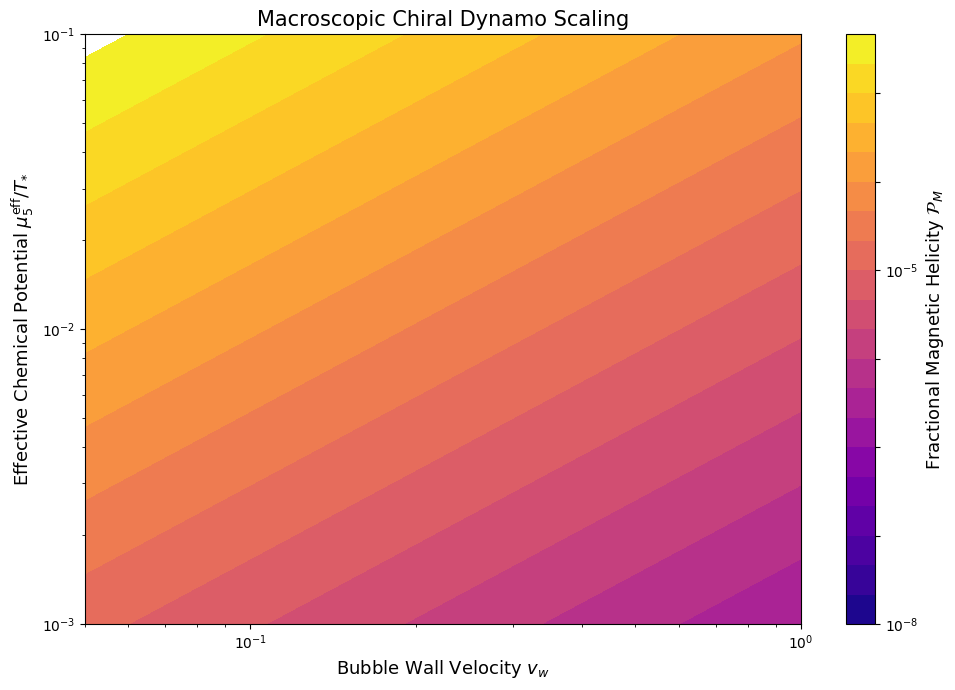

In [23]:
# Figure 7.2: Fractional Magnetic Helicity Heatmap
fig, ax = plt.subplots(figsize=(10, 7))

# Define the parameter space
v_w_axis = np.logspace(np.log10(0.05), np.log10(1.0), 200)
mu5_axis = np.logspace(-3, -1, 200)
V_W, MU5 = np.meshgrid(v_w_axis, mu5_axis)

# Calculate the fractional magnetic helicity
P_M = calc_p_m(MU5, V_W)

# Set the contour levels for the heatmap
levels = np.logspace(-8, -3, 21)

# Plot the heatmap using filled contours
cf = ax.contourf(V_W, MU5, P_M, levels=levels, cmap="plasma", norm=LogNorm(vmin=1e-8, vmax=1e-3))

# Colorbar
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r"Fractional Magnetic Helicity $\mathcal{P}_M$", fontsize=13)

# Labels and title
ax.set_title("Macroscopic Chiral Dynamo Scaling", fontsize=15)
ax.set_xlabel(r"Bubble Wall Velocity $v_w$", fontsize=13)
ax.set_ylabel(r"Effective Chemical Potential $\mu_5^{\rm eff} / T_{*}$", fontsize=13)

# Log scaling and limits
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(5e-2, 1e0)
ax.set_ylim(1e-3, 1e-1)

# Adjust the layout to prevent clipping
fig.tight_layout() 

# Save the figure if it doesn't already exist
outpath = PROJECT_ROOT / "figures" / "pm_heatmap.pdf"
outpath.parent.mkdir(parents=True, exist_ok=True)
if not outpath.exists():
    fig.savefig(outpath, dpi=300)

plt.show()

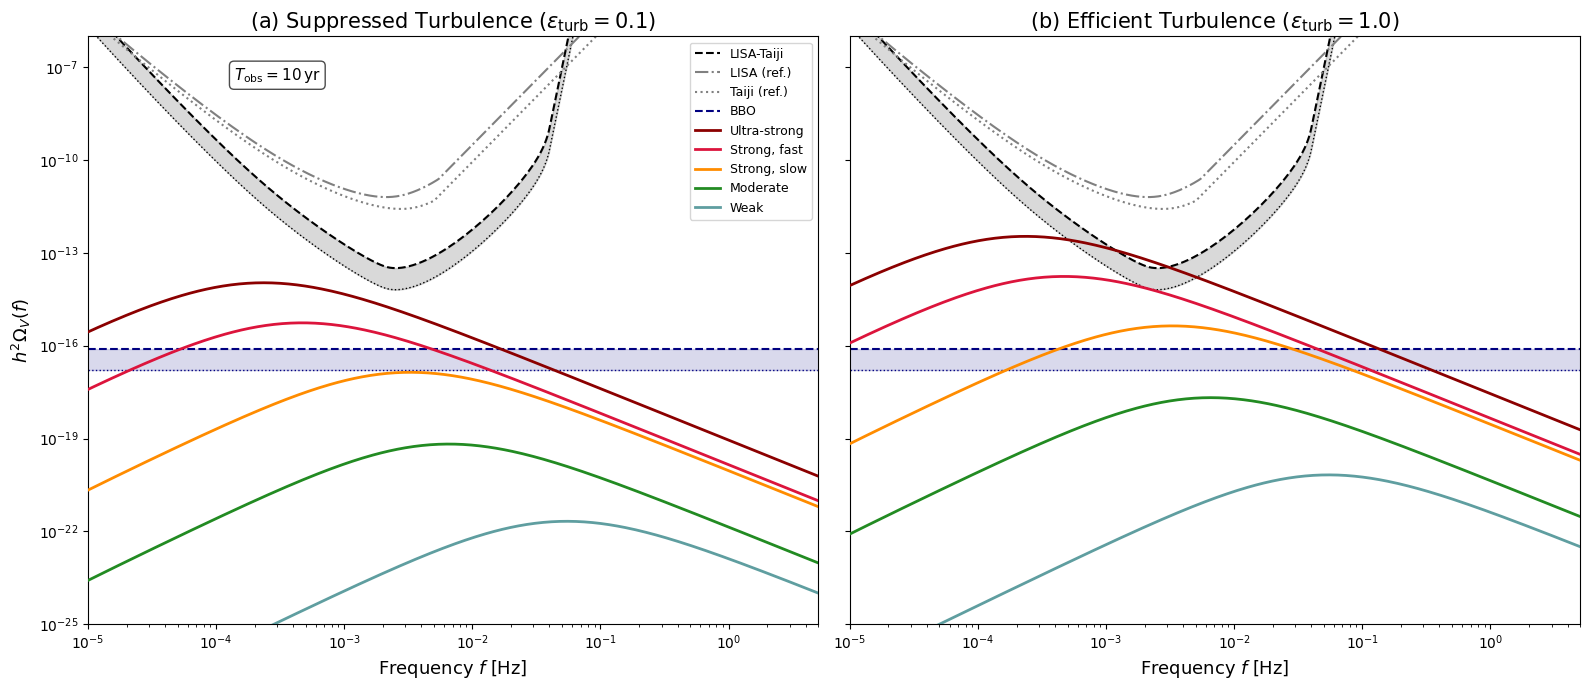

In [24]:
# Figure 7.3: Chiral GW vs LISA-Taiji Chirality Sensitivity

# Load LISA/Taiji/LISA-Taiji chirality PLS data from CSV files
xipls_folder = PROJECT_ROOT / "external" / "AlbertoRoper-GW_turbulence" / "detector_sensitivity"
f_lt, xi_lt = _load_xipls_csv(os.path.join(xipls_folder, "LISA_Taiji_XiPLS.csv"))
f_l, xi_l = _load_xipls_csv(os.path.join(xipls_folder, "LISA_XiPLS.csv"))
f_t, xi_t = _load_xipls_csv(os.path.join(xipls_folder, "Taiji_XiPLS.csv"))

# Create a 1x2 panel figure for chiral GW detectability
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Common frequency axis
f_axis = np.logspace(-6, 2, 500)

# Calculate scales for both SNR=1 and SNR=5
period_new = 10 # Observation period in years
scale_xipls_1 = calc_scale(1, period_new)
scale_xipls_5 = calc_scale(5, period_new)

# Setup the two cases for the loop
eps_turb_values = [0.1, 1.0]
panel_titles = [r"(a) Suppressed Turbulence ($\epsilon_{\rm turb} = 0.1$)", 
                r"(b) Efficient Turbulence ($\epsilon_{\rm turb} = 1.0$)"]

for ax, eps_turb, title in zip(axes, eps_turb_values, panel_titles):
    
    # --- PLOT DETECTOR SENSITIVITIES (SNR=1 to SNR=5 Ribbons) ---
    
    # LISA-Taiji ribbon
    ax.fill_between(f_lt, xi_lt * scale_xipls_1, xi_lt * scale_xipls_5, color="black", alpha=0.15, zorder=1)
    ax.loglog(f_lt, xi_lt * scale_xipls_5, label=r"LISA-Taiji", color="black", linestyle="--", lw=1.5, zorder=2)
    ax.loglog(f_lt, xi_lt * scale_xipls_1, color="black", linestyle=":", lw=1.0, zorder=2)
    
    # Individual LISA / Taiji
    ax.loglog(f_l, xi_l * scale_xipls_5, label="LISA (ref.)", color="gray", linestyle="-.", lw=1.5, zorder=2)
    ax.loglog(f_t, xi_t * scale_xipls_5, label="Taiji (ref.)", color="gray", linestyle=":", lw=1.5, zorder=2)

    # BBO Ω_V ribbon (Seto 2007, flat-band approximation)
    omega_v_bbo_1 = 8e-17 * (1 / 5) * (period_new / 10)**(-0.5) 
    omega_v_bbo_5 = 8e-17 * (5 / 5) * (period_new / 10)**(-0.5) 
    ax.fill_between(f_axis, omega_v_bbo_1, omega_v_bbo_5, color="navy", alpha=0.15, zorder=1)
    ax.axhline(y=omega_v_bbo_5, label=r"BBO", color="navy", linestyle="--", lw=1.5, zorder=2)
    ax.axhline(y=omega_v_bbo_1, color="navy", linestyle=":", lw=1.0, zorder=2)

    # --- PLOT CHIRAL GW SPECTRA ---
    
    for bp in bps_fopt:
        
        # Calculate the fractional magnetic helicity
        p_m = calc_p_m(0.1, bp["v_w"])
        
        # Calculate peak frequency and amplitude for the turbulence channel (Caprini 2016)
        f_peak = calc_f_peak(bp["beta_H_star"], bp["v_w"], channel="t")
        h2omega_peak = calc_h2omega_peak(bp["alpha"], bp["beta_H_star"], bp["v_w"], channel="t", eps_turb=eps_turb)
        
        # Use ONLY the standard full Caprini S_turb
        shape = calc_spectral_shape(f_axis, f_peak, channel="t", h_star=calc_h_star())
        h2omega_v = p_m * h2omega_peak * shape
        
        ax.loglog(f_axis, h2omega_v, label=bp["label"], color=bp["color"], linestyle="-", lw=2.0, zorder=4)

    # --- FORMATTING ---
    ax.set_title(title, fontsize=15)
    ax.set_xlabel(r"Frequency $f$ [Hz]", fontsize=13)
    ax.set_xlim(1e-5, 5e0)
    ax.set_ylim(1e-25, 1e-6)
    
    if ax == axes[0]:

        # Add a text box indicating the observation time
        props = dict(boxstyle="round", facecolor="white", alpha=0.7)
        ax.text(0.20, 0.95, r"$T_{\rm obs}=10\,\mathrm{yr}$", 
                transform=ax.transAxes, fontsize=11, verticalalignment="top", bbox=props)
        
        # Only add the ylabel to the leftmost plot
        ax.set_ylabel(r"$h^2 \Omega_{V}(f)$", fontsize=13)
        ax.legend(fontsize=9, loc="upper right")

# Adjust the layout to remove whitespace between plots
fig.tight_layout() 

# Save the figure if it doesn't already exist
outpath = PROJECT_ROOT / "figures" / "gw_chirality.pdf"
outpath.parent.mkdir(parents=True, exist_ok=True)
if not outpath.exists():
    fig.savefig(outpath, dpi=300)

plt.show()

In [25]:
# Compute and plot minima of LISA-Taiji XiPLS for SNR=1 and SNR=5 (T_obs=10 yr)
period_new = 10  # years
scale_xi_1 = calc_scale(1, period_new)
scale_xi_5 = calc_scale(5, period_new)

xi_1 = xi_lt * scale_xi_1
xi_5 = xi_lt * scale_xi_5

# Find minima
idx_min_1 = np.argmin(xi_1)
idx_min_5 = np.argmin(xi_5)

f_min_1, val_min_1 = f_lt[idx_min_1], xi_1[idx_min_1]
f_min_5, val_min_5 = f_lt[idx_min_5], xi_5[idx_min_5]

print(f"SNR=1, T=10 yr -> min xi = {val_min_1:.3e} at f = {f_min_1:.3e} Hz")
print(f"SNR=5, T=10 yr -> min xi = {val_min_5:.3e} at f = {f_min_5:.3e} Hz")

# Chiral h2omega_v values at the detector minima
f_axis = np.logspace(-6, 2, 10000)

def calc_h2omega_v(bp, eps_turb):
    f_peak_t = calc_f_peak(bp["beta_H_star"], bp["v_w"], channel="t")
    h2omega_peak_t = calc_h2omega_peak(bp["alpha"], bp["beta_H_star"], bp["v_w"], channel="t", eps_turb=eps_turb)
    h2omega_t = h2omega_peak_t * calc_spectral_shape(f_axis, f_peak_t, channel="t", h_star=calc_h_star())
    p_m = calc_p_m(0.1, bp["v_w"])
    h2omega_v = p_m * h2omega_t
    return h2omega_v

bp1 = bps_fopt[0]
bp2 = bps_fopt[1]
bp5 = bps_fopt[4]

h2omega_v_bp1_eps01 = calc_h2omega_v(bp1, 0.1)
h2omega_v_bp5_eps01 = calc_h2omega_v(bp5, 0.1)
h2omega_v_bp1_eps1 = calc_h2omega_v(bp1, 1.0)
h2omega_v_bp2_eps1 = calc_h2omega_v(bp2, 1.0)

h2omega_v_bp1_eps01_at_fmin5 = np.interp(f_min_5, f_axis, h2omega_v_bp1_eps01)
h2omega_v_bp5_eps01_max = np.max(h2omega_v_bp5_eps01)
h2omega_v_bp1_eps1_at_fmin5 = np.interp(f_min_5, f_axis, h2omega_v_bp1_eps1)
h2omega_v_bp2_eps1_at_fmin1 = np.interp(f_min_1, f_axis, h2omega_v_bp2_eps1)

print(f"eps_turb=0.1, bp1 at f_min_5 -> h2omega_v = {h2omega_v_bp1_eps01_at_fmin5:.3e}")
print(f"eps_turb=0.1, bp5 max h2omega_v -> h2omega_v_max = {h2omega_v_bp5_eps01_max:.3e}")
print(f"eps_turb=1.0, bp1 at f_min_5 -> h2omega_v = {h2omega_v_bp1_eps1_at_fmin5:.3e}")
print(f"eps_turb=1.0, bp2 at f_min_1 -> h2omega_v = {h2omega_v_bp2_eps1_at_fmin1:.3e}")

SNR=1, T=10 yr -> min xi = 6.442e-15 at f = 2.514e-03 Hz
SNR=5, T=10 yr -> min xi = 3.221e-14 at f = 2.514e-03 Hz
eps_turb=0.1, bp1 at f_min_5 -> h2omega_v = 1.455e-15
eps_turb=0.1, bp5 max h2omega_v -> h2omega_v_max = 2.108e-22
eps_turb=1.0, bp1 at f_min_5 -> h2omega_v = 4.602e-14
eps_turb=1.0, bp2 at f_min_1 -> h2omega_v = 5.726e-15


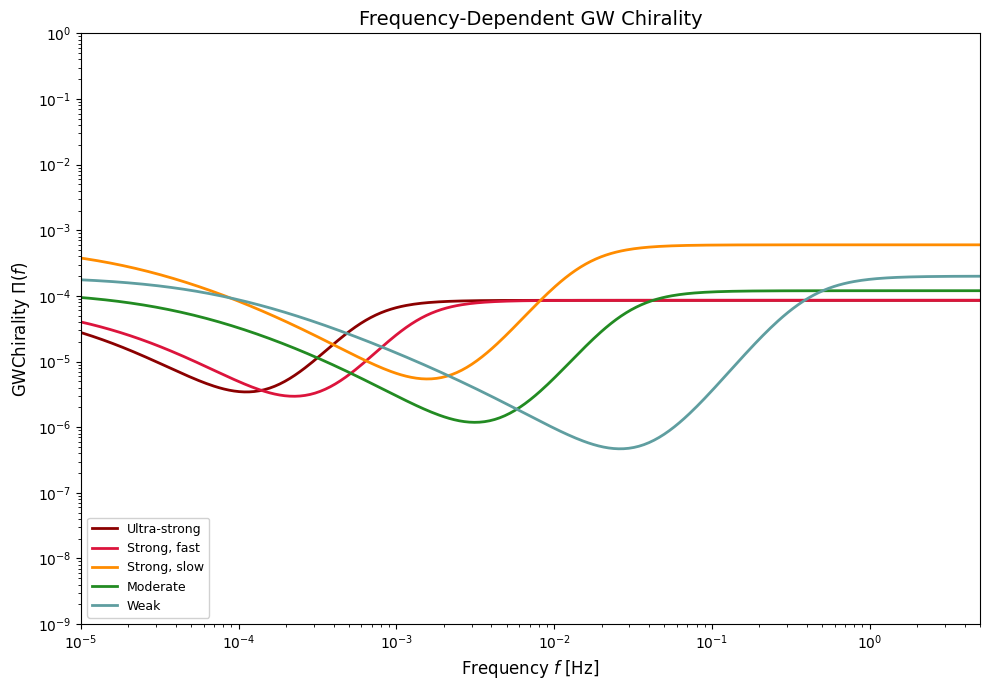

In [26]:
# Frequency-Dependent GW Chirality
fig, ax = plt.subplots(figsize=(10, 7))

# Common frequency axis
f_axis = np.logspace(-6, 2, 500)

# Chirality Spectrum from FOPT Benchmarks
for bp in bps_fopt:
    
    # Calculate peak frequency and amplitude for the sound wave channel
    f_peak_s = calc_f_peak(bp["beta_H_star"], bp["v_w"], channel="s")
    h2omega_peak_s = calc_h2omega_peak(bp["alpha"], bp["beta_H_star"], bp["v_w"], channel="s")
    
    # Generate the sound wave spectrum
    h2omega_s = h2omega_peak_s * calc_spectral_shape(f_axis, f_peak_s, channel="s")

    # Calculate peak frequency and amplitude for the turbulence channel
    f_peak_t = calc_f_peak(bp["beta_H_star"], bp["v_w"], channel="t")
    h2omega_peak_t = calc_h2omega_peak(bp["alpha"], bp["beta_H_star"], bp["v_w"], channel="t", eps_turb=1.0)

    # Generate the turbulence spectrum
    h2omega_t = h2omega_peak_t * calc_spectral_shape(f_axis, f_peak_t, channel="t", h_star=calc_h_star())
    
    # Calculate the total GW spectrum (sound wave + turbulence)
    h2omega_gw = h2omega_s + h2omega_t

    # Calculate fractional magnetic helicity
    p_m = calc_p_m(0.1, bp["v_w"])

    # Calculate the GW chirality spectrum
    pi_f = p_m * h2omega_t / h2omega_gw # Fractional helicity contribution to the total spectrum
    ax.loglog(f_axis, pi_f, label=bp["label"], color=bp["color"], linestyle="-", lw=2)

# Labels and title
ax.set_title("Frequency-Dependent GW Chirality", fontsize=14)
ax.set_xlabel(r"Frequency $f$ [Hz]", fontsize=12)
ax.set_ylabel(r"GWChirality $\Pi(f)$", fontsize=12)

# Set limits
ax.set_xlim(1e-5, 5e0)
ax.set_ylim(1e-9, 1e0)

# Add legend
ax.legend(fontsize=9, loc="lower left", framealpha=0.9)

# Adjust the layout
fig.tight_layout()

# Save the figure if it doesn't already exist
outpath = PROJECT_ROOT / "figures" / "gw_chirality_freq.pdf"
outpath.parent.mkdir(parents=True, exist_ok=True)
if not outpath.exists():
    fig.savefig(outpath, dpi=300)

plt.show()